# Generate plot for the paper

In [1]:
%cd ..
%pwd  # should be "llm-adaptation"

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load Online data

In [3]:
online = pd.read_csv(Path("results/farm/summary.csv"))

In [4]:
palette = {
    "baseline": "tab:gray",
    "ppo_10steps": "dimgray",
    "ppo_10steps_rs5": "gray",
    "q_network_10steps": "darkgray",
    "q_network_10steps_rs5": "lightgray",
    "gpt4omini": "tab:red",
    # "claude35haiku": "tab:blue",
    "gemini20flash": "tab:green",
    "gpt4o": "tab:orange",
    "claude37sonnet": "tab:cyan",
    "o3mini": "tab:pink",
}

In [5]:
baseline_names = {
    "baseline": "Rule-based",
    "ppo_10steps": "PPO",
    "ppo_10steps_rs5": "PPO + reward shaping",
    "q_network_10steps": "Q-Network",
    "q_network_10steps_rs5": "Q-Network + reward shaping",
}
llm_names = {
    "gpt4omini": "GPT-4o mini",
    # "claude35haiku": "Claude 3.5 Haiku",
    "gemini20flash": "Gemini 2.0 Flash",
    "gpt4o": "GPT-4o",
    "claude37sonnet": "Claude 3.7 Sonnet",
    "o3mini": "OpenAI o3-mini",
}
all_names = {**baseline_names, **llm_names}
online['LLM'] = online['llm'].map(all_names)
palette_baselines = {v: palette[k] for k, v in baseline_names.items()}
palette_LLM = {v: palette[k] for k, v in llm_names.items()}
online["params"] = online["params"].replace({"Rule-based Smart": "Rule-based"})

In [6]:
online

,llm,params,damage,LLM
0,baseline,Rule-based,31.0,Rule-based
1,baseline,Rule-based,31.0,Rule-based
2,baseline,Rule-based,27.0,Rule-based
3,baseline,Rule-based,32.0,Rule-based
4,baseline,Rule-based,24.0,Rule-based
...,...,...,...,...
71,o3mini,Step-by-Step,44.0,OpenAI o3-mini
72,o3mini,Step-by-Step,48.0,OpenAI o3-mini
73,o3mini,Hinted,30.0,OpenAI o3-mini
74,o3mini,Hinted,34.0,OpenAI o3-mini


## Load Offline data

In [7]:
offline = pd.read_csv(Path("logs/generated/no_battery/summary.csv"))

In [8]:
offline['LLM'] = offline['llm'].map({
    "4o": "GPT-4o",
    "o3": "OpenAI o3-mini",
})

In [9]:
offline

,llm,params,repeat,version,damage,LLM
0,4o,Default,2,1,291,GPT-4o
1,4o,Default,2,1,272,GPT-4o
2,4o,Default,2,1,293,GPT-4o
3,4o,Default,2,1,216,GPT-4o
4,4o,Default,2,1,252,GPT-4o
...,...,...,...,...,...,...
170,o3,Hinted,4,2,264,OpenAI o3-mini
171,o3,Hinted,4,2,206,OpenAI o3-mini
172,o3,Hinted,4,2,280,OpenAI o3-mini
173,o3,Hinted,4,2,245,OpenAI o3-mini


In [10]:
offline_v1 = offline[offline["version"] == 1]
offline_v2 = offline[offline["version"] == 2]
offline_v2.loc[:, "params"] = offline_v2["params"] + "\nUpdated"

In [11]:
agg_v1 = offline_v1.groupby(["params", "LLM", "repeat"]).agg({"damage": "mean"}).reset_index()
agg_v2 = offline_v2.groupby(["params", "LLM", "repeat"]).agg({"damage": "mean"}).reset_index()
offline_agg = pd.concat([agg_v1, agg_v2])
offline_agg

,params,LLM,repeat,damage
0,Default,GPT-4o,2,264.8
1,Default,GPT-4o,3,256.4
2,Default,GPT-4o,4,280.8
3,Default,OpenAI o3-mini,2,278.6
4,Default,OpenAI o3-mini,3,285.0
5,Default,OpenAI o3-mini,4,241.4
6,Hinted,GPT-4o,2,260.2
7,Hinted,GPT-4o,3,266.4
8,Hinted,GPT-4o,4,260.2
9,Hinted,OpenAI o3-mini,2,252.8


## Plot

In [12]:
rows_baselines = ["Rule-based", "RL"]
rows_llm = ["Default", "Hinted", "Step-by-Step", "History", "Memory", "Ensemble-First"]

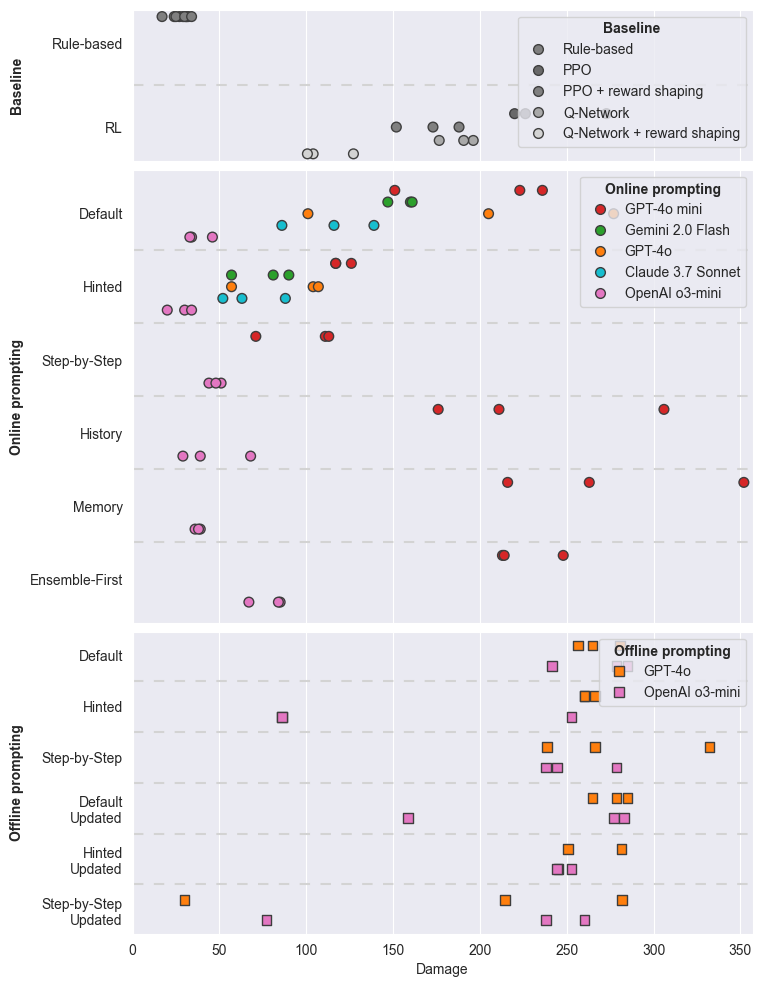

In [25]:
fig, [ax_b, ax_on, ax_off] = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(8, 12), height_ratios=[1, 3, 2])
plot_kwargs = {
    "dodge": True,
    "jitter": False,
    "size": 7,
    "linewidth": 1,
}

# Baselines
plot_b = sns.stripplot(x="damage", y="params", hue="LLM", data=online[online["params"].isin(rows_baselines)], ax=ax_b, palette=palette_baselines, hue_order=palette_baselines.keys(), order=rows_baselines, **plot_kwargs)
ax_b.get_legend().set_title("Baseline", prop={'weight': 'bold'})
sns.move_legend(ax_b, "upper right")
ax_b.set_ylabel("Baseline", weight='bold')
# add lines separating params
for y in range(0, len(rows_baselines) - 1):
    ax_b.plot([0, online['damage'].max() + 5], [y + 0.5, y + 0.5], linestyle=(0, (5, 5)), c='lightgray')

# Online
plot_on = sns.stripplot(x="damage", y="params", hue="LLM", data=online[online["params"].isin(rows_llm)], ax=ax_on, palette=palette_LLM, hue_order=palette_LLM.keys(), order=rows_llm, **plot_kwargs)
ax_on.get_legend().set_title("Online prompting", prop={'weight': 'bold'})
sns.move_legend(ax_on, "upper right")
ax_on.set_ylabel("Online prompting", weight='bold')
# add lines separating params
for y in range(0, len(rows_llm) - 1):
    ax_on.plot([0, online['damage'].max() + 5], [y + 0.5, y + 0.5], linestyle=(0, (5, 5)), c='lightgray')

# Offline
offline_llms = ["GPT-4o", "OpenAI o3-mini"]
sns.stripplot(x="damage", y="params", hue="LLM", data=offline_agg, ax=ax_off, palette=palette_LLM, hue_order=offline_llms, marker="s", **plot_kwargs)
ax_off.get_legend().set_title("Offline prompting", prop={'weight': 'bold'})
sns.move_legend(ax_off, "upper right")
ax_off.set_ylabel("Offline prompting", weight='bold')
# add lines separating params
for y in range(0, len(offline_agg["params"].unique()) - 1):
  ax_off.plot([0, online['damage'].max() + 5], [y + 0.5, y + 0.5], linestyle=(0, (5, 5)), c='lightgray')


fig.subplots_adjust(wspace=0, hspace=0.03)
fig.align_ylabels([ax_b, ax_on, ax_off])
plt.xlim(0, online['damage'].max() + 5)
plt.xlabel("Damage")
plt.savefig("results/farm/plot.pdf", bbox_inches="tight")
plt.show()